# Neural Networks

In this notebook, you will classify handwritten digits from the [MNIST dataset](http://yann.lecun.com/exdb/mnist/) using (i) a softmax regression model (as a baseline) and (ii) a convolutional neural network.

Author(s): Raj Magesh Gauthaman (rgautha1@jh.edu)

## Setup

In [1]:
from __future__ import annotations
from tqdm import tqdm

import numpy as np
import torch
import torch.nn as nn
from torchvision.datasets import MNIST
from torchvision import transforms as tr
from torchdata.datapipes.map import SequenceWrapper
from torchdata.datapipes.iter import IterDataPipe
from functools import partial
import torchvision.transforms as tr
import pandas as pd

def apply_transform(x, transform):
    return transform(x)

class SoftmaxRegression(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=28 * 28, out_features=10),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layers(x)


class NeuralNetwork(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=1024, out_features=1024),
            nn.ReLU(inplace=True),
            nn.Linear(in_features=1024, out_features=10),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layers(x)
    
class NeuralNetworkSingle(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=4608, out_features=1024),
            nn.ReLU(inplace=True),
            nn.Linear(in_features=1024, out_features=10),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layers(x)


def create_datapipe(train: bool, batch_size: int, buffer_size: int = 10000) -> tuple[IterDataPipe, IterDataPipe]:
    datapipe = (
        SequenceWrapper(MNIST(root="mnist", train=train, download=True))
        .to_iter_datapipe()
    )
    if buffer_size is not None:
        datapipe = datapipe.cycle().shuffle(buffer_size=buffer_size)

    images, labels = datapipe.unzip(sequence_length=2)
    images = images.map(partial(apply_transform, transform=tr.ToTensor())).batch(batch_size=batch_size)
    labels = labels.batch(batch_size=batch_size)

    return images, labels

/Users/chitniss/miniforge/envs/homework/lib/python3.13/site-packages/torchdata/datapipes/__init__.py:18: UserWarning: 
################################################################################
WARNING!
The 'datapipes', 'dataloader2' modules are deprecated and will be removed in a
future torchdata release! Please see https://github.com/pytorch/data/issues/1196
to learn more and leave feedback.
################################################################################

  deprecation_warning()


## Training and evaluating the model

In [2]:
def modelInit(model_type: str, device: torch.device) -> nn.Module:
    if model_type == "softmax":
        model = SoftmaxRegression().to(device)
    elif model_type == "nn2":
        model = NeuralNetwork().to(device)
    elif model_type == "nn1":
        model = NeuralNetworkSingle().to(device)
    else:
        raise ValueError(f"Unknown model type: {model_type}")
    return model

def trainModel(model: nn.Module, device: torch.device, optimizer: torch.optim.Optimizer, loss_function: nn.Module, batch_size: int, n_batches: int) -> None:
    datapipe_train = create_datapipe(train=True, batch_size=batch_size)
    model.train()
    batch = 0
    for images, labels in tqdm(zip(*datapipe_train), desc="batch", leave=False):
        images = torch.stack(images).to(device=device)
        labels = torch.Tensor(labels).to(dtype=torch.long, device=device)

        optimizer.zero_grad()
        predicted_labels = model(images)
        loss = loss_function(predicted_labels, labels)
        loss.backward()
        optimizer.step()

        batch += 1
        if batch == n_batches:
            break
        
def runModel(model: nn.Module, device: torch.device, batch_size: int, print:bool=False) -> float:
    datapipe_test = create_datapipe(train=False, batch_size=batch_size, buffer_size=None)

    model.eval()
    correct_predictions = 0
    total = 0
    for images, labels in tqdm(zip(*datapipe_test), desc="batch", leave=False):
        images = torch.stack(images).to(device=device)
        labels = torch.Tensor(labels).to(dtype=torch.long, device=device)

        predicted_labels = model(images)
        correct_predictions += (predicted_labels.argmax(dim=-1) == labels).sum()
        total += len(predicted_labels)

    accuracy = correct_predictions / total
    if print: print(f"accuracy = {accuracy:.03}")
    return accuracy.item()

In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model = modelInit("nn2", device)

### Train model

In [4]:
optimizer = torch.optim.Adam(model.parameters())
loss_function = nn.CrossEntropyLoss(reduction="mean")
n_batches = 1000
batch_size = 100

In [5]:
trainModel(model, device, optimizer, loss_function, batch_size, n_batches)

### Evaluate model

In [6]:
accuracy =runModel(model, device, batch_size)

### Get accuracy values over repeated trainings

In [7]:
n_model_samples = 10

In [8]:
model_accuracyDf = pd.DataFrame(columns=["model_type", "sample_index", "accuracy", "n_batches"])
for i in range(n_model_samples):
    model = modelInit("nn2", device)
    optimizer = torch.optim.Adam(model.parameters())
    trainModel(model, device, optimizer, loss_function, batch_size, n_batches)
    accuracy = runModel(model, device, batch_size)
    model_accuracyDf.loc[len(model_accuracyDf)] = {"model_type": "nn2", "sample_index": i, "accuracy": accuracy, "n_batches": n_batches}

### Run untrained model

In [9]:
for i in range(n_model_samples):
    modelUT = modelInit("nn2", device)
    accuracyUT = runModel(modelUT, device, batch_size)
    model_accuracyDf.loc[len(model_accuracyDf)] = {"model_type": "nn2_ut", "sample_index": i, "accuracy": accuracyUT, "n_batches": n_batches}

### Run single layer model

In [10]:
for i in range(n_model_samples):
    modelSingle = modelInit("nn1", device)
    optimizerSingle = torch.optim.Adam(modelSingle.parameters())
    trainModel(modelSingle
            , device, optimizerSingle, loss_function, batch_size, n_batches)
    accuracySingle = runModel(modelSingle, device, batch_size)
    model_accuracyDf.loc[len(model_accuracyDf)] = {"model_type": "nn1", "sample_index": i, "accuracy": accuracySingle, "n_batches": n_batches}

### Softmax regression

In [11]:
n_batch_vec = np.array([10, 100, 1000, 10000])
for n_batch in n_batch_vec:
    for i in range(n_model_samples):
        modelSoft = modelInit("softmax", device)
        optimizerSoft = torch.optim.Adam(modelSoft.parameters())
        trainModel(modelSoft
                , device, optimizerSoft, loss_function, batch_size, n_batch)
        accuracySoft = runModel(modelSoft, device, batch_size)
        model_accuracyDf.loc[len(model_accuracyDf)] = {"model_type": "softmax", "sample_index": i, "accuracy": accuracySoft, "n_batches": n_batch}

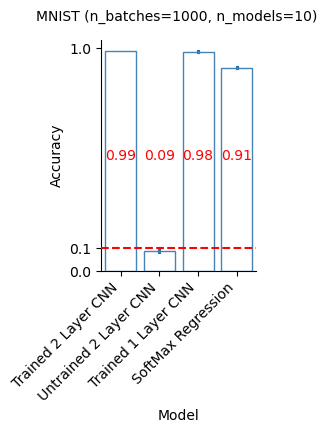

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(2, 3))
labels = ["Trained 2 Layer CNN", "Untrained 2 Layer CNN", "Trained 1 Layer CNN", "SoftMax Regression"]
sns.barplot(data=model_accuracyDf.query(f'n_batches=={n_batches}'), x="model_type", y="accuracy", zorder=10, ax=ax, fill=False, edgecolor='steelblue', linewidth=1)
for i, l in enumerate(model_accuracyDf['model_type'].unique().tolist()):
    ax.text(i+0.4, 0.5, model_accuracyDf.query(f'n_batches=={n_batches}').query(f'model_type == "{l}"')['accuracy'].mean().round(2), rotation=0, ha="right", color='r', zorder=30)
ax.axhline(y=0.1, color='red', linestyle='--', zorder=20)
fig.suptitle(f'MNIST (n_batches={n_batches}, n_models={n_model_samples})', fontsize = 10)
ax.set_yticks([0, 0.1, 1])
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy")
sns.despine()
plt.savefig("results/model_accuracy.pdf", bbox_inches='tight', dpi=300)

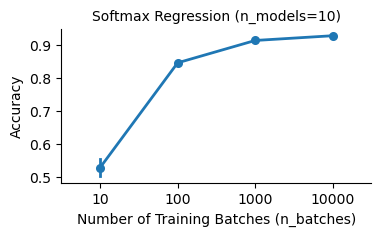

In [100]:
plt.figure(figsize=(4, 2))
sns.pointplot(data=model_accuracyDf.query('model_type=="softmax"'), x="n_batches", y="accuracy",  linewidth=2)
plt.title("Softmax Regression (n_models=10)", fontsize = 10)
plt.xlabel("Number of Training Batches (n_batches)")
plt.ylabel("Accuracy")
sns.despine()
plt.savefig("results/accuracy_vs_batches_softmax.pdf", bbox_inches='tight', dpi=300)

## Questions

1. What do you expect the accuracy of an untrained model to be on the MNIST dataset? Why? Try evaluating an untrained model. What is the accuracy you obtain? (3 points)
2. What is the loss function used here? Describe it. Why is it appropriate for a classification task? (4 points)
3. Try using a neural network with only one convolutional layer (the `NeuralNetwork` class provided has two: remove the second one!) You will have to adjust the number of input features to your first linear layer. Do you find a accuracy difference between one-layer convolutional network and a two-layer convolutional network? Explain why/why not. (6 points)
4. Try using the simple softmax regression model. Compare the results to those from the convolutional neural network. (2 points)
5. Try changing the number of training batches for the softmax regression model (try 10, 100, 1000, and 10,000). How does the accuracy change? (5 points)